# Convolutional Neural Networks - Build Model
---
In this notebook, we build and train a **CNN** to classify images from the CIFAR-10 database. 
* The code provided here are **almost** working. You are required to build up a CNN model and train it.
* Make sure you covered implementations of the **TODO**s in this notebook

The images in this database are small color images that fall into one of ten classes; some example images are pictured below.

<img src='cifar_data.png' width=50% height=50% />

### Optional: Use [CUDA](http://pytorch.org/docs/stable/cuda.html) if Available



In [19]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is not available.  Training on CPU ...


## Load the [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)


In [20]:
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20
# percentage of training set to use as validation
valid_size = 0.2

# convert data to a normalized torch.FloatTensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# choose the training and test datasets
train_data = datasets.CIFAR10('data', train=True,
                              download=True, transform=transform)
test_data = datasets.CIFAR10('data', train=False,
                             download=True, transform=transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

# specify the image classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

### Visualize a Batch of Training Data

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

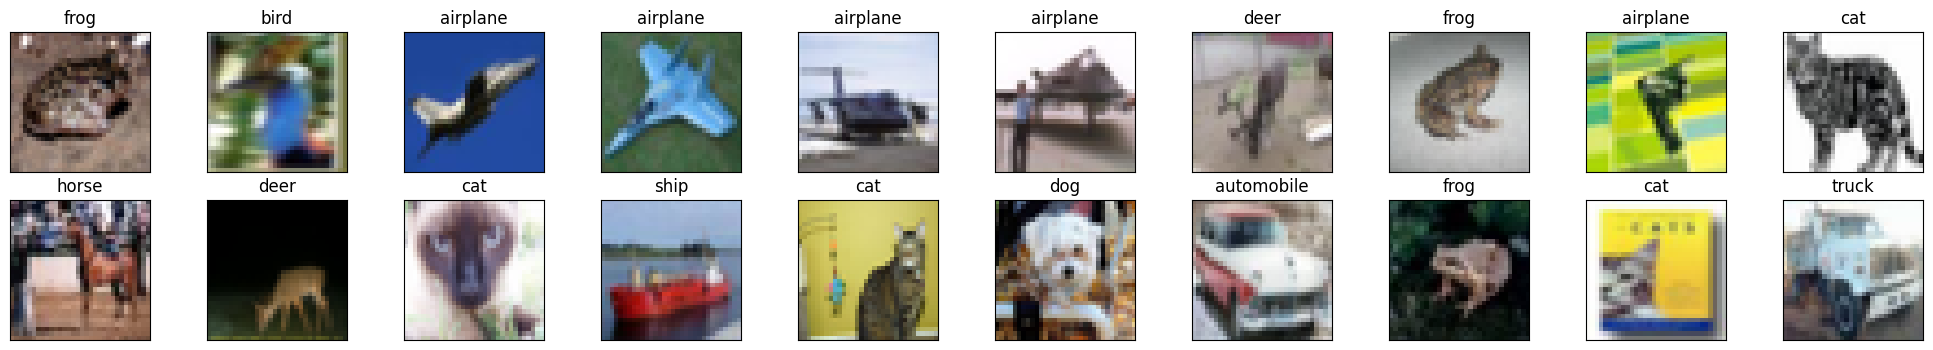

In [22]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

### View an Image in More Detail


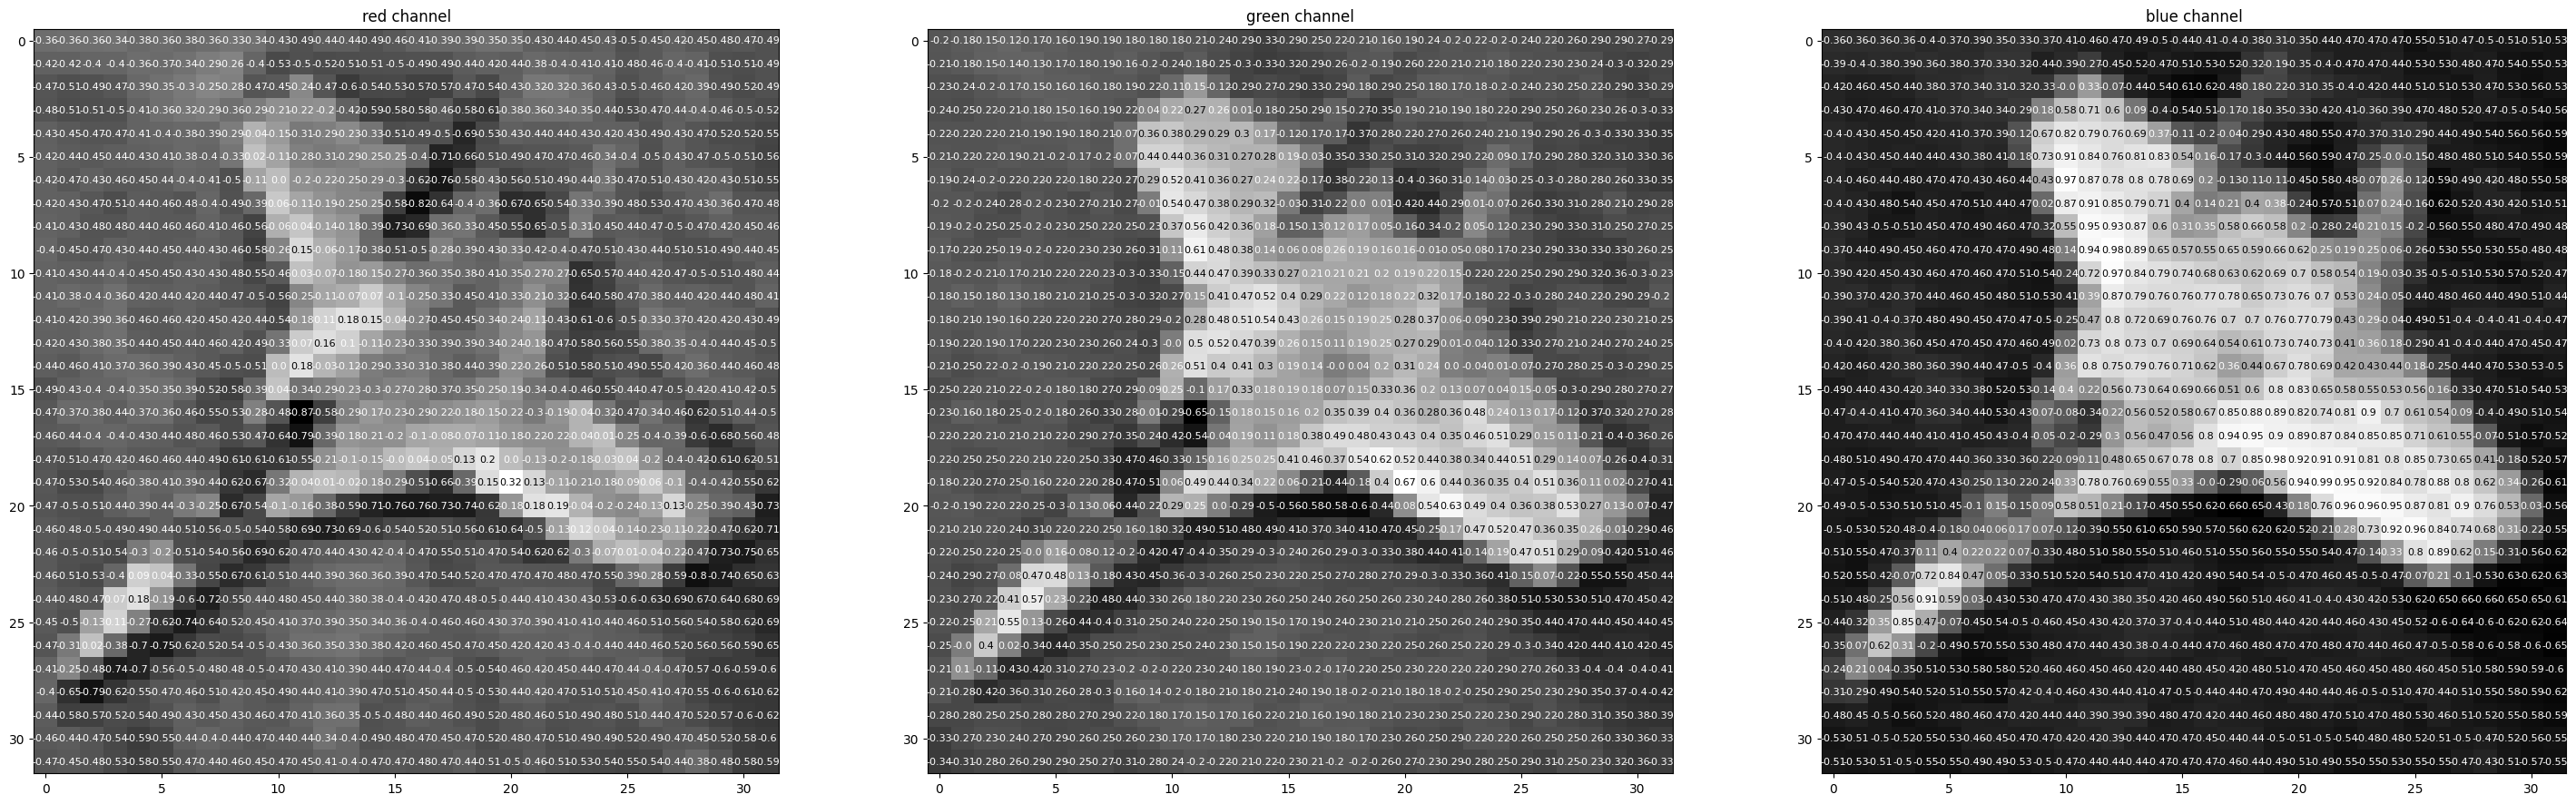

In [23]:
rgb_img = np.squeeze(images[3])
channels = ['red channel', 'green channel', 'blue channel']

fig = plt.figure(figsize = (36, 36)) 
for idx in np.arange(rgb_img.shape[0]):
    ax = fig.add_subplot(1, 3, idx + 1)
    img = rgb_img[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(channels[idx])
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            val = round(img[x][y],2) if img[x][y] !=0 else 0
            ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center', size=8,
                    color='white' if img[x][y]<thresh else 'black')



The following is a complete implementation with ≥3 conv layers, pooling, dropout, and FC head (10 classes).

In [24]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture (custom, not pretrained)
# Input: 32x32x3. After conv1+pool: 16x16, conv2+pool: 8x8, conv3+pool: 4x4, 64 channels -> flatten 4*4*64 = 1024
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # convolutional layers (3 layers, 32x32x3 -> 16x16x16 -> 8x8x32 -> 4x4x64)
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # fully connected: 4*4*64 = 1024 -> 256 -> 10
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# sanity check: dummy forward to confirm output shape [batch_size, 10]
model = Net()
dummy = torch.randn(2, 3, 32, 32)
assert model(dummy).shape == (2, 10), "Output shape should be (batch, 10)"
print("Sanity check passed: output shape (batch_size, 10)")
print(model)

if train_on_gpu:
    model.cuda()

Sanity check passed: output shape (batch_size, 10)
Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [25]:
import torch.optim as optim

# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer (SGD first; compare with Adam below)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

## Train the Network


In [ ]:
# number of epochs to train the model
n_epochs = 25

train_losses = []
valid_losses = []
valid_loss_min = np.Inf

for epoch in range(1, n_epochs + 1):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

    model.eval()
    for batch_idx, (data, target) in enumerate(valid_loader):
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        output = model(data)
        loss = criterion(output, target)
        valid_loss += loss.item() * data.size(0)

    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))

    if valid_loss <= valid_loss_min:
        print('  Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
            valid_loss_min, valid_loss))
        torch.save(model.state_dict(), 'model_trained.pt')
        valid_loss_min = valid_loss

### Training vs Validation Loss Curves 

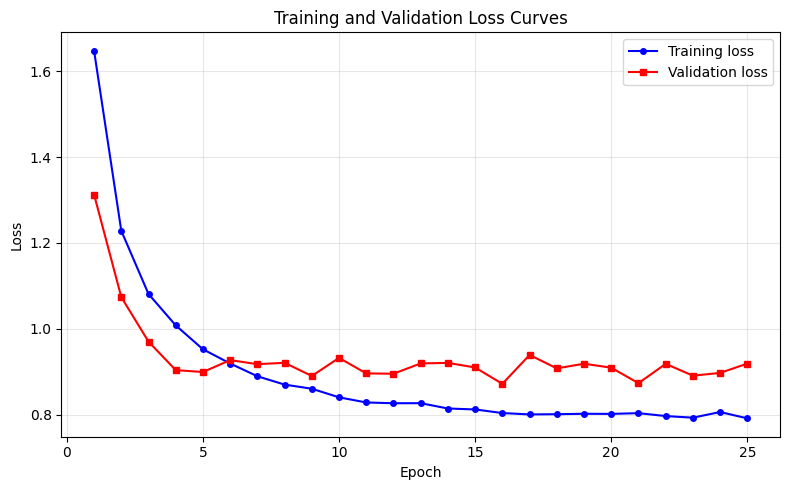

In [ ]:
# Plot loss curves for report
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', markersize=4, label='Training loss')
ax.plot(range(1, len(valid_losses) + 1), valid_losses, 'r-s', markersize=4, label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Load the Model with the Lowest Validation Loss
This is the model we will use for testing.

In [ ]:
model.load_state_dict(torch.load('model_trained.pt'))

<All keys matched successfully>

In [ ]:
# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
for batch_idx, (data, target) in enumerate(test_loader):
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    output = model(data)
    loss = criterion(output, target)
    test_loss += loss.item() * data.size(0)
    _, pred = torch.max(output, 1)
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    for i in range(data.size(0)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

test_loss = test_loss / len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            int(class_correct[i]), int(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A' % (classes[i]))

total_correct = sum(class_correct)
total = sum(class_total)
print('\nTest Accuracy (Overall): %2d%% (%d/%d)' % (100. * total_correct / total, int(total_correct), int(total)))

Test Loss: 0.903694

Test Accuracy of airplane: 72% (722/1000)
Test Accuracy of automobile: 84% (848/1000)
Test Accuracy of  bird: 62% (625/1000)
Test Accuracy of   cat: 59% (590/1000)
Test Accuracy of  deer: 70% (707/1000)
Test Accuracy of   dog: 48% (484/1000)
Test Accuracy of  frog: 74% (748/1000)
Test Accuracy of horse: 68% (687/1000)
Test Accuracy of  ship: 79% (796/1000)
Test Accuracy of truck: 74% (743/1000)

Test Accuracy (Overall): 69% (6950/10000)


### Visualize Sample Test Results (Report figure: green = correct, red = wrong)

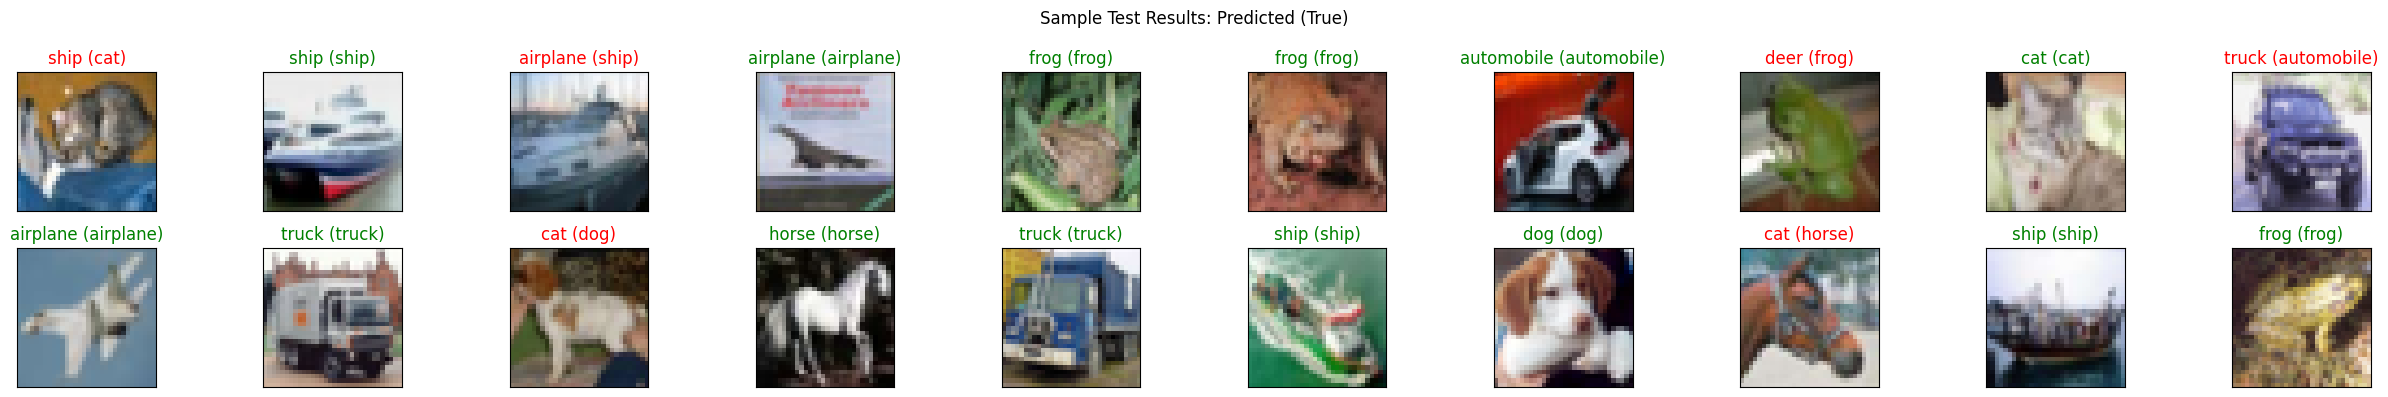

In [ ]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

if train_on_gpu:
    images_cuda = images.cuda()
else:
    images_cuda = images
output = model(images_cuda)
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())
images_np = images.numpy()

fig = plt.figure(figsize=(25, 4))
n_show = min(20, len(images_np))
for idx in range(n_show):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    imshow(images_np[idx])
    true_label = labels[idx].item() if hasattr(labels[idx], 'item') else labels[idx]
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[true_label]),
                 color=("green" if preds[idx] == true_label else "red"))
plt.suptitle('Sample Test Results: Predicted (True)', fontsize=12)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2A: Visualize early-layer feature maps (first conv layer)
For **3 test images from different classes**, we show the original image and **at least 8 feature maps** from **conv1**. Layer name and channel indices are labeled.

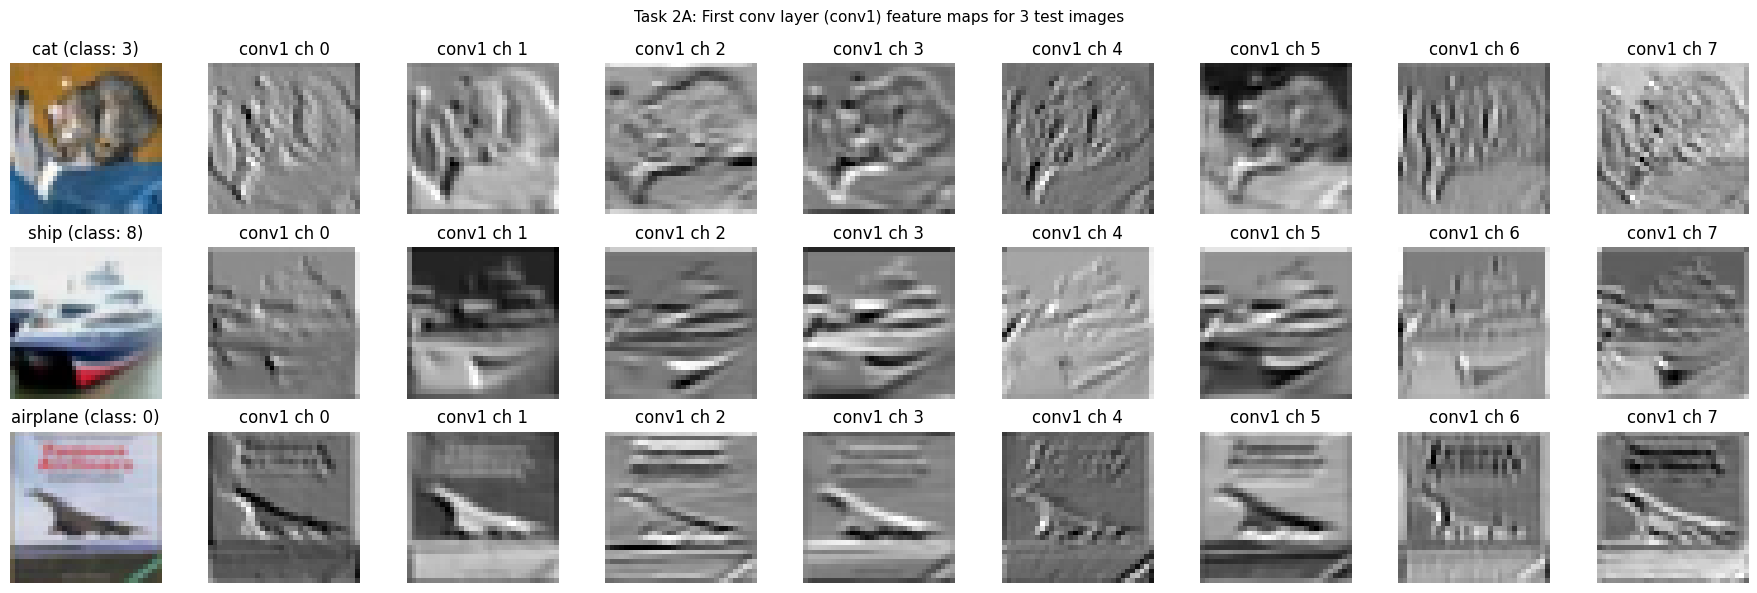

In [ ]:
# Capture conv1 outputs via forward hook
conv1_outputs = None

def conv1_hook(module, inp, out):
    global conv1_outputs
    conv1_outputs = out.detach()

handle = model.conv1.register_forward_hook(conv1_hook)

# Get 3 test images from 3 different classes
test_images_list = []
test_labels_list = []
seen_classes = set()
for data, target in test_loader:
    for i in range(data.size(0)):
        if target[i].item() not in seen_classes and len(seen_classes) < 3:
            seen_classes.add(target[i].item())
            test_images_list.append(data[i:i+1])
            test_labels_list.append(target[i].item())
        if len(test_images_list) >= 3:
            break
    if len(test_images_list) >= 3:
        break

# Plot: for each of 3 images, show original + 8 feature maps from conv1
n_maps = 8
fig, axes = plt.subplots(3, 1 + n_maps, figsize=(2 * (1 + n_maps), 6))
for row, (img_tensor, label) in enumerate(zip(test_images_list, test_labels_list)):
    if train_on_gpu:
        img_tensor = img_tensor.cuda()
    _ = model(img_tensor)
    # conv1_outputs: (1, 16, 16, 16) after pool is in forward; we need conv1 only
    # Re-run: we need output of conv1 before pool. Register hook on conv1, then in forward we have conv1(x).
    # So conv1_outputs will be (1, 16, 32, 32) before pool. Let me check our forward: x = self.pool(F.relu(self.conv1(x))).
    # So hook on conv1 gives conv1(x), i.e. (1, 16, 32, 32). We want to show 8 channels. Use channels 0..7.
    fm = conv1_outputs[0]  # (16, 32, 32)
    # Original (unnormalized for display)
    img_np = img_tensor[0].cpu().numpy()
    img_disp = img_np / 2 + 0.5
    img_disp = np.transpose(img_disp, (1, 2, 0))
    axes[row, 0].imshow(img_disp)
    axes[row, 0].set_title('{} (class: {})'.format(classes[label], label))
    axes[row, 0].axis('off')
    for k in range(n_maps):
        axes[row, k+1].imshow(fm[k].cpu().numpy(), cmap='gray')
        axes[row, k+1].set_title('conv1 ch {}'.format(k))
        axes[row, k+1].axis('off')
handle.remove()

plt.suptitle('Task 2A: First conv layer (conv1) feature maps for 3 test images', fontsize=11)
plt.tight_layout()
plt.savefig('task2a_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2B: Maximally activating images for 3 filters
We pick **one conv layer** (conv2) and **3 filters**. For each filter, activation = **max** over its 2D feature map. We score all test images, select **top 5**, and visualize them with (true class, activation score).

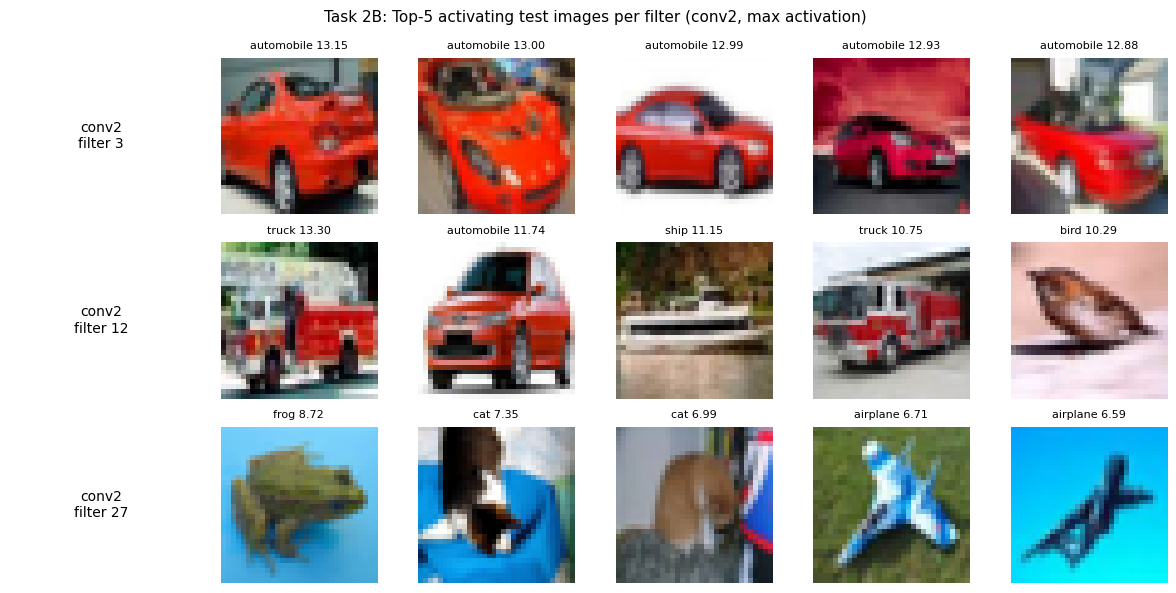

In [ ]:
# Task 2B: conv2 layer, filters 3, 12, 27 (indices in conv2 output channels)
CHOSEN_LAYER = 'conv2'
FILTER_INDICES = [3, 12, 27]
TOP_K = 5
ACTIVATION_METRIC = 'max'  # or 'mean'

conv2_outputs = None
def conv2_hook(module, inp, out):
    global conv2_outputs
    conv2_outputs = out.detach()

handle2 = model.conv2.register_forward_hook(conv2_hook)

# Score all test images: for each image get conv2 output, then for each filter compute scalar activation
# conv2 output shape: (B, 32, 8, 8)
all_scores = {f: [] for f in FILTER_INDICES}  # list of (score, image_idx, label)
all_test_images = []
all_test_labels = []

model.eval()
start_idx = 0
for batch_idx, (data, target) in enumerate(test_loader):
    if train_on_gpu:
        data = data.cuda()
    with torch.no_grad():
        _ = model(data)
    # conv2_outputs: (B, 32, 8, 8)
    B = conv2_outputs.size(0)
    for i in range(B):
        img_idx = start_idx + i
        all_test_images.append(data[i].cpu())
        all_test_labels.append(target[i].item())
        for fi, ch in enumerate(FILTER_INDICES):
            map_2d = conv2_outputs[i, ch].cpu().numpy()
            if ACTIVATION_METRIC == 'max':
                score = float(np.max(map_2d))
            else:
                score = float(np.mean(map_2d))
            all_scores[ch].append((score, img_idx, target[i].item()))
    start_idx += B

handle2.remove()

# Top 5 per filter
top5_per_filter = {}
for ch in FILTER_INDICES:
    all_scores[ch].sort(key=lambda x: x[0], reverse=True)
    top5_per_filter[ch] = all_scores[ch][:TOP_K]

# Visualize: one row per filter, 5 images per row; first column = filter label
fig, axes = plt.subplots(len(FILTER_INDICES), TOP_K + 1, figsize=(2 * (TOP_K + 1), 2 * len(FILTER_INDICES)))
for row, ch in enumerate(FILTER_INDICES):
    axes[row, 0].text(0.5, 0.5, 'conv2\nfilter {}'.format(ch), ha='center', va='center', fontsize=10)
    axes[row, 0].axis('off')
    for col, (score, img_idx, label) in enumerate(top5_per_filter[ch]):
        ax = axes[row, col + 1]
        img = all_test_images[img_idx].numpy()
        img_disp = img / 2 + 0.5
        ax.imshow(np.transpose(img_disp, (1, 2, 0)))
        ax.set_title('{} {:.2f}'.format(classes[label], score), fontsize=8)
        ax.axis('off')

plt.suptitle('Task 2B: Top-5 activating test images per filter (conv2, max activation)', fontsize=11)
plt.tight_layout()
plt.savefig('task2b_top5_activating.png', dpi=150, bbox_inches='tight')
plt.show()